In [320]:
pip install sportsdataverse

Note: you may need to restart the kernel to use updated packages.


In [321]:
pip install polars


Note: you may need to restart the kernel to use updated packages.


In [322]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [323]:
import sportsdataverse.nhl as nhl
import polars as pl
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.special import expit

In [324]:
def safe(label, thunk):
    try:
        out = thunk()
        print(f'✅ {label}')
        return out
    except Exception as e:  # noqa: BLE001 -- demo resilience
        print(f'⏭️  {label}: unavailable right now ({type(e).__name__})')
        return None

In [325]:

sched = safe('load schedule 2024', lambda: nhl.load_nhl_schedule(seasons=[2026]))

✅ load schedule 2024


In [326]:
if sched is not None:
    print('release schedule shape:', sched.shape)
    cols = ['game_id', 'game_date', 'home_team_abbr', 'away_team_abbr', 'home_score', 'away_score', 'game_type']
    reg = sched.filter(pl.col("game_type") == "R").sort("game_date")
    out = reg.select([c for c in cols])
else:
    out = 'release loader unavailable'
out

release schedule shape: (1394, 35)


game_id,game_date,home_team_abbr,away_team_abbr,home_score,away_score,game_type
i32,str,str,str,i32,i32,str
2025020001,"""2025-10-07""","""FLA""","""CHI""",3,2,"""R"""
2025020002,"""2025-10-07""","""NYR""","""PIT""",0,3,"""R"""
2025020003,"""2025-10-07""","""LAK""","""COL""",1,4,"""R"""
2025020004,"""2025-10-08""","""TOR""","""MTL""",5,2,"""R"""
2025020005,"""2025-10-08""","""WSH""","""BOS""",1,3,"""R"""
…,…,…,…,…,…,…
2025021308,"""2026-04-16""","""WPG""","""SJS""",1,6,"""R"""
2025021309,"""2026-04-16""","""UTA""","""STL""",3,5,"""R"""
2025021310,"""2026-04-16""","""CGY""","""LAK""",3,1,"""R"""


In [327]:
def get_record(schedule: pl.DataFrame):
    util = schedule.select(['home_team_abbr', "away_team_abbr", "home_score", "away_score"])
    home = util.group_by("home_team_abbr").agg(
        pl.col("home_score").sum().alias("goal_for"),
        pl.col("away_score").sum().alias("goal_against"),
        (pl.col("home_score") > pl.col("away_score")).sum().alias("wins"),
        (pl.col("away_score") > pl.col("home_score")).sum().alias("loses")
    )
    away = util.group_by("away_team_abbr").agg(
        pl.col("away_score").sum().alias("goal_for"),
        pl.col("home_score").sum().alias("goal_against"),
        (pl.col("away_score") > pl.col("home_score")).sum().alias("wins"),
        (pl.col("home_score") > pl.col("away_score")).sum().alias("loses")
    ) 
    record = (
        pl.concat([
            home.rename({"home_team_abbr": "team"}),
            away.rename({"away_team_abbr": "team"}),
        ])
        .group_by("team")
        .sum()
    )
    
    record.insert_column(5, (pl.col("goal_for") / pl.col("goal_against")).alias("score_ratio"))
    record.insert_column(6, (pl.col("wins") /( pl.col("wins") + pl.col("loses"))).alias("win_pctg"))
    return record

In [328]:
def loss(alpha, x, y):
    return np.sum((y - expit(alpha * np.log(x))) ** 2)

record = get_record(reg)
x = record["score_ratio"].to_numpy()
y = record["win_pctg"].to_numpy()

res = minimize_scalar(fun=loss, args=(x,y), bounds=(0,10), method="bounded")
print(res.x, res.fun)
opt_alpha = res.x

1.9504689458337978 0.030627974488968965


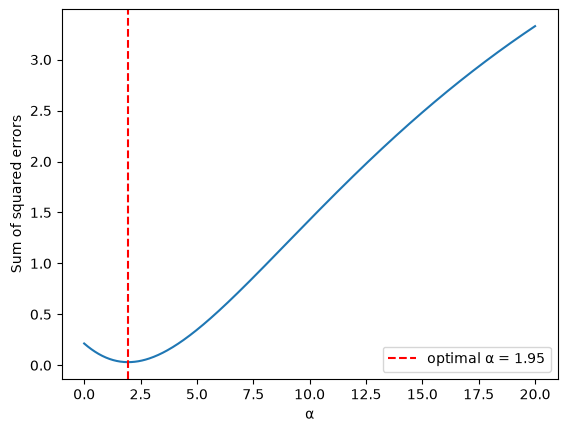

In [329]:
import matplotlib.pyplot as plt

alphas = np.linspace(0, 20, 500)
losses = [loss(a, x, y) for a in alphas]

plt.plot(alphas, losses)
plt.axvline(res.x, color="red", linestyle="--", label=f"optimal α = {res.x:.2f}")
plt.xlabel("α")
plt.ylabel("Sum of squared errors")
plt.legend()
plt.show()

In [330]:
def pyth_win_pctg( score_ratio):
    return expit(opt_alpha * np.log(score_ratio))

In [331]:
record.insert_column(7, (pyth_win_pctg(pl.col("score_ratio"))).alias("pyth_win_pctg"))

team,goal_for,goal_against,wins,loses,score_ratio,win_pctg,pyth_win_pctg
str,i32,i32,u32,u32,f64,f64,f64
"""SJS""",251,292,39,43,0.859589,0.47561,0.426754
"""UTA""",268,240,43,39,1.116667,0.52439,0.553601
"""PHI""",250,243,43,39,1.028807,0.52439,0.513845
"""DAL""",279,226,50,32,1.234513,0.609756,0.601308
"""WSH""",263,244,43,39,1.077869,0.52439,0.536499
…,…,…,…,…,…,…,…
"""NYI""",233,241,43,39,0.966805,0.52439,0.483545
"""CAR""",296,240,53,29,1.233333,0.646341,0.600861
"""CBJ""",253,253,40,42,1.0,0.487805,0.5


In [332]:
first_half = reg.slice(0,reg.height // 2)
sec_half = reg.slice(reg.height // 2)

record_first = get_record(first_half)
record_first.insert_column(7, (pyth_win_pctg(pl.col("score_ratio"))).alias("pyth_win_pctg"))

record_second = get_record(sec_half)
record_second.insert_column(7, (pyth_win_pctg(pl.col("score_ratio"))).alias("pyth_win_pctg"))


print(record_first, record_second)

shape: (32, 8)
┌──────┬──────────┬──────────────┬──────┬───────┬─────────────┬──────────┬───────────────┐
│ team ┆ goal_for ┆ goal_against ┆ wins ┆ loses ┆ score_ratio ┆ win_pctg ┆ pyth_win_pctg │
│ ---  ┆ ---      ┆ ---          ┆ ---  ┆ ---   ┆ ---         ┆ ---      ┆ ---           │
│ str  ┆ i32      ┆ i32          ┆ u32  ┆ u32   ┆ f64         ┆ f64      ┆ f64           │
╞══════╪══════════╪══════════════╪══════╪═══════╪═════════════╪══════════╪═══════════════╡
│ CGY  ┆ 111      ┆ 121          ┆ 18   ┆ 23    ┆ 0.917355    ┆ 0.439024 ┆ 0.458037      │
│ OTT  ┆ 133      ┆ 129          ┆ 20   ┆ 20    ┆ 1.031008    ┆ 0.5      ┆ 0.514886      │
│ COL  ┆ 164      ┆ 91           ┆ 31   ┆ 9     ┆ 1.802198    ┆ 0.775    ┆ 0.759299      │
│ DAL  ┆ 143      ┆ 113          ┆ 25   ┆ 16    ┆ 1.265487    ┆ 0.609756 ┆ 0.612837      │
│ NYR  ┆ 114      ┆ 117          ┆ 20   ┆ 23    ┆ 0.974359    ┆ 0.465116 ┆ 0.487337      │
│ …    ┆ …        ┆ …            ┆ …    ┆ …     ┆ …           ┆ …        ┆ 

In [333]:
record = record.join(
    record_first.select(
        "team",
        pl.col("win_pctg").alias("f_half_w_pctg"),
        pl.col("pyth_win_pctg").alias("f_half_pyth_w_pctg")
    ),
    on="team",
    how="left",
).join(
    record_second.select(
            "team",
            pl.col("win_pctg").alias("s_half_w_pctg"),
            pl.col("pyth_win_pctg").alias("s_half_pyth_w_pctg")
        ),
        on="team",
        how="left",
)
print(record)

shape: (32, 12)
┌──────┬──────────┬─────────────┬──────┬───┬─────────────┬─────────────┬─────────────┬─────────────┐
│ team ┆ goal_for ┆ goal_agains ┆ wins ┆ … ┆ f_half_w_pc ┆ f_half_pyth ┆ s_half_w_pc ┆ s_half_pyth │
│ ---  ┆ ---      ┆ t           ┆ ---  ┆   ┆ tg          ┆ _w_pctg     ┆ tg          ┆ _w_pctg     │
│ str  ┆ i32      ┆ ---         ┆ u32  ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│      ┆          ┆ i32         ┆      ┆   ┆ f64         ┆ f64         ┆ f64         ┆ f64         │
╞══════╪══════════╪═════════════╪══════╪═══╪═════════════╪═════════════╪═════════════╪═════════════╡
│ SJS  ┆ 251      ┆ 292         ┆ 39   ┆ … ┆ 0.487805    ┆ 0.432432    ┆ 0.463415    ┆ 0.421027    │
│ UTA  ┆ 268      ┆ 240         ┆ 43   ┆ … ┆ 0.452381    ┆ 0.519576    ┆ 0.6         ┆ 0.58597     │
│ PHI  ┆ 250      ┆ 243         ┆ 43   ┆ … ┆ 0.525       ┆ 0.532474    ┆ 0.52381     ┆ 0.496145    │
│ DAL  ┆ 279      ┆ 226         ┆ 50   ┆ … ┆ 0.609756    ┆ 0.612837    ┆ 0.

In [334]:
win_pctg = record.select(["f_half_w_pctg", "s_half_w_pctg"])
win_pctg.corr()

f_half_w_pctg,s_half_w_pctg
f64,f64
1.0,0.543485
0.543485,1.0


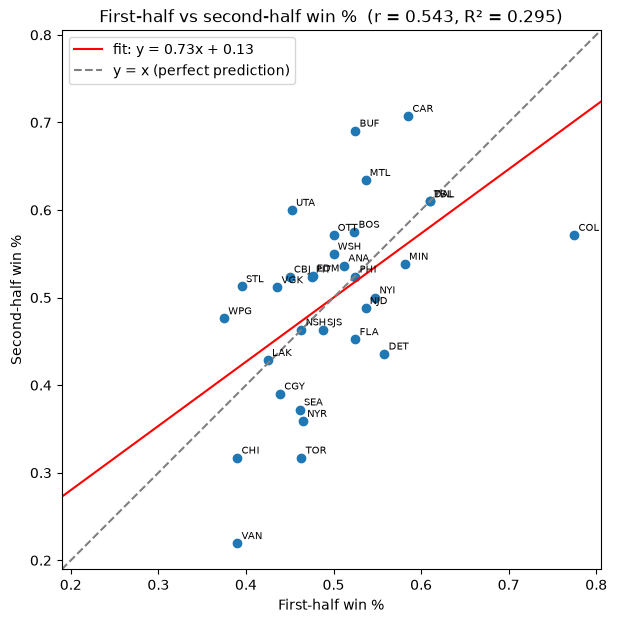

In [335]:
fx = record["f_half_w_pctg"].to_numpy()
sy = record["s_half_w_pctg"].to_numpy()
teams = record["team"].to_list()

r = np.corrcoef(fx, sy)[0, 1]
slope, intercept = np.polyfit(fx, sy, 1)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(fx, sy)

# team labels
for t, xi, yi in zip(teams, fx, sy):
    ax.annotate(t, (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

# fitted line + perfect-prediction line
lims = np.array([min(fx.min(), sy.min()) - 0.03, max(fx.max(), sy.max()) + 0.03])
ax.plot(lims, slope * lims + intercept, color="red", label=f"fit: y = {slope:.2f}x + {intercept:.2f}")
ax.plot(lims, lims, color="gray", linestyle="--", label="y = x (perfect prediction)")

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("First-half win %")
ax.set_ylabel("Second-half win %")
ax.set_title(f"First-half vs second-half win %  (r = {r:.3f}, R² = {r**2:.3f})")
ax.legend()
plt.show()


In [336]:
pyth_vs_sec_half = record.select(["f_half_pyth_w_pctg", "s_half_w_pctg"])
pyth_vs_sec_half.corr()

f_half_pyth_w_pctg,s_half_w_pctg
f64,f64
1.0,0.489199
0.489199,1.0


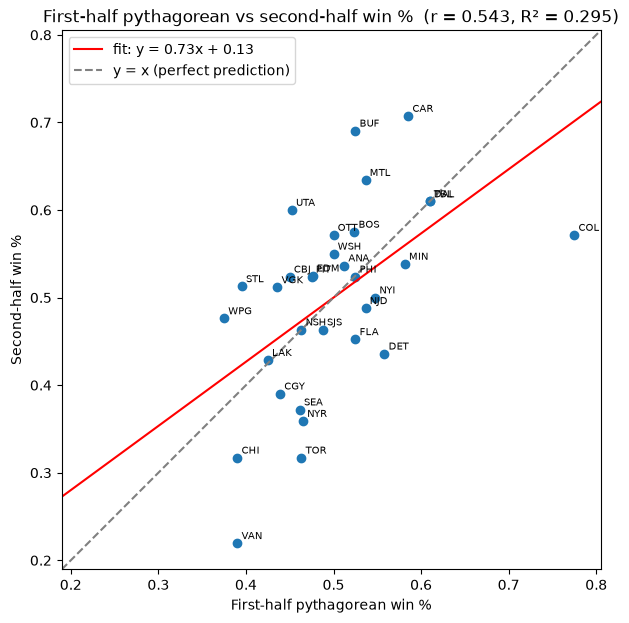

In [337]:
fx = record["f_half_w_pctg"].to_numpy()
sy = record["s_half_w_pctg"].to_numpy()
teams = record["team"].to_list()

r = np.corrcoef(fx, sy)[0, 1]
slope, intercept = np.polyfit(fx, sy, 1)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(fx, sy)

# team labels
for t, xi, yi in zip(teams, fx, sy):
    ax.annotate(t, (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

# fitted line + perfect-prediction line
lims = np.array([min(fx.min(), sy.min()) - 0.03, max(fx.max(), sy.max()) + 0.03])
ax.plot(lims, slope * lims + intercept, color="red", label=f"fit: y = {slope:.2f}x + {intercept:.2f}")
ax.plot(lims, lims, color="gray", linestyle="--", label="y = x (perfect prediction)")

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("First-half pythagorean win %")
ax.set_ylabel("Second-half win %")
ax.set_title(f"First-half pythagorean vs second-half win %  (r = {r:.3f}, R² = {r**2:.3f})")
ax.legend()
plt.show()

In [338]:
record.insert_column(10, ((pl.col("f_half_w_pctg") - pl.col("f_half_pyth_w_pctg"))).alias("f_half_res_w"))
record.insert_column(13, ((pl.col("s_half_w_pctg") - pl.col("s_half_pyth_w_pctg"))).alias("s_half_res_w"))
record.select(["team", "f_half_res_w", "s_half_res_w"])

team,f_half_res_w,s_half_res_w
str,f64,f64
"""SJS""",0.055372,0.042388
"""UTA""",-0.067195,0.01403
"""PHI""",-0.007474,0.027664
"""DAL""",-0.00308,0.020387
"""WSH""",-0.053184,0.03058
…,…,…
"""NYI""",0.047619,0.033305
"""CAR""",0.04495,0.049448
"""CBJ""",-0.01562,-0.011117


In [339]:
res_w_pctg = record.select(["f_half_res_w", "s_half_res_w"])
res_w_pctg.corr()

f_half_res_w,s_half_res_w
f64,f64
1.0,0.22785
0.22785,1.0


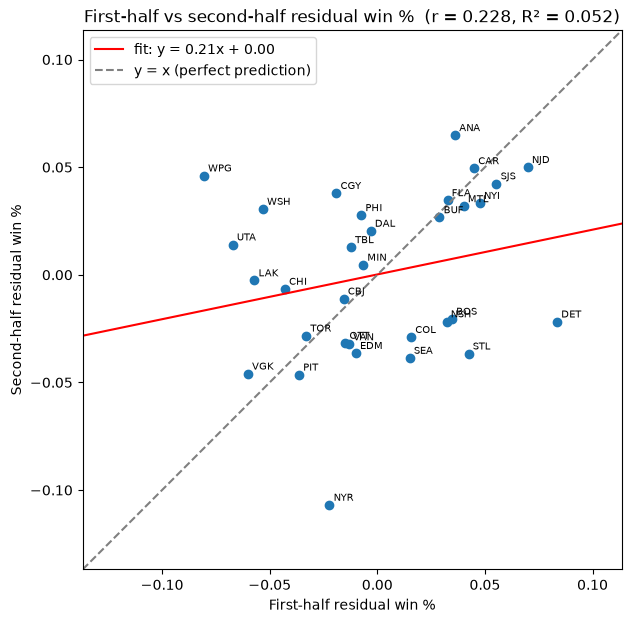

In [340]:
fx = record["f_half_res_w"].to_numpy()
sy = record["s_half_res_w"].to_numpy()
teams = record["team"].to_list()

r = np.corrcoef(fx, sy)[0, 1]
slope, intercept = np.polyfit(fx, sy, 1)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(fx, sy)

# team labels
for t, xi, yi in zip(teams, fx, sy):
    ax.annotate(t, (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

# fitted line + perfect-prediction line
lims = np.array([min(fx.min(), sy.min()) - 0.03, max(fx.max(), sy.max()) + 0.03])
ax.plot(lims, slope * lims + intercept, color="red", label=f"fit: y = {slope:.2f}x + {intercept:.2f}")
ax.plot(lims, lims, color="gray", linestyle="--", label="y = x (perfect prediction)")

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("First-half residual win %")
ax.set_ylabel("Second-half residual win %")
ax.set_title(f"First-half vs second-half residual win %  (r = {r:.3f}, R² = {r**2:.3f})")
ax.legend()
plt.show()

## Why might this model be an inadequate representation of reality?

Hockey games don't end in ties, and the model treats every result the same. Overtime and shootout results are close to coin flips. Shootout winners also get an extra goal added to the final score, which inflates goals for and against. An overtime loss counts as a full loss here, but in the real standings it earns a point.


It only uses goals. It ignores goaltending, special teams, shot quality (xG), and empty-net goals, which pile up at the end of close games. It also ignores score effects: teams that are ahead play more defensively.


It assumes a team stays the same all season. Trades, injuries, coaching changes and goalie slumps all change how good a team is between the two halves.


It ignores context: strength of schedule, home/away splits, back-to-back games.


The samples are small and the method has a leak. There are only about 41 games per half and 32 data points. The halves also have uneven game counts (39–43). α was fitted on the full season and then used to evaluate each half, so it's partly in-sample.


The evidence shows it. Pythagorean win % from the first half predicted second-half win % slightly worse than actual win % did (r = 0.49 vs 0.54). That's unusual, and it suggests lots of noise at this sample size.
## What decision in sport management might be affected by this analysis?

Trade deadline, buy or sell: a team winning more than its goal differential predicts (positive residual) will probably regress. Management shouldn't pay a lot to "go for it" on that record alone.


Firing or extending coaches: a coach whose team underperforms its Pythagorean record may be unlucky rather than bad.


Contracts and player evaluation: "clutch" reputations built on one-goal wins mostly don't last. Your residuals correlate at only r = 0.23 between halves, which isn't statistically significant (p = 0.21 with n = 32).


Planning: goal differential is a better basis for next season's projections, and for betting lines, than the win-loss record.
## How might this analysis change the way fans think about the sport?
Standings partly reflect luck. A lot of the gap between a team's record and its goal differential is random and tends to even out, so a "hot" team that's beating its expected record will likely cool down.


Fans should doubt "they just know how to win close games" stories. Your data shows that ability barely carries from one half of the season to the next.


Goal differential is a better guide than wins to how good a team really is, especially early in the season.


It can ease frustration: a team with a good goal differential but a poor record is probably better than it looks.

In [341]:
from scipy.stats import pearsonr
r, p = pearsonr(record["f_half_res_w"].to_numpy(), record["s_half_res_w"].to_numpy())
print(f"r = {r:.3f}, p = {p:.3f}")


r = 0.228, p = 0.210
